<a href="https://colab.research.google.com/github/MohamedRedaElFaiz/Projet-Deep-Learning-EMSI/blob/main/Partie_2_CNN_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Partie II : CNN et Vision par Ordinateur (Dataset: MNIST Classique)

### 1. Pourquoi le MLP est peu adapté aux images?
[cite_start]Un MLP aplatit l'image en un vecteur plat 1D, ce qui détruit complètement l'organisation 2D naturelle et la relation spatiale locale entre les pixels voisins[cite: 19]. [cite_start]De plus, pour des images réelles à forte résolution, un MLP engendre une explosion massive du nombre de paramètres à apprendre, saturant rapidement la mémoire[cite: 23, 28].

[cite_start]Les CNN résolvent ces problèmes grâce à trois idées fondatrices[cite: 30]:
* [cite_start]**Localité** : Une sortie dépend uniquement d'un petit voisinage local de pixels[cite: 31].
* [cite_start]**Partage des poids** : Le même filtre (noyau) glisse et est réutilisé sur toute l'image[cite: 32, 49].
* [cite_start]**Hiérarchie des représentations** : Les couches profondes combinent progressivement les motifs simples (bords, contours) pour former des structures et concepts plus complexes[cite: 33, 34].

In [4]:
import torch

def corr2d_manuel(X, K):
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y

def pool2d_manuel(X, pool_size=(2,2), mode='max'):
    p_h, p_w = pool_size
    Y = torch.zeros((X.shape[0] // p_h, X.shape[1] // p_w))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            region = X[i*p_h:(i+1)*p_h, j*p_w:(j+1)*p_w]
            if mode == 'max':
                Y[i, j] = region.max()
            elif mode == 'avg':
                Y[i, j] = region.mean()
    return Y

X_test = torch.tensor([[0., 1., 2.], [3., 4., 5.], [6., 7., 8.]])
K_test = torch.tensor([[0., 1.], [2., 3.]])
print(f"Validation Corrélation manuelle (Attendu 19.0) : {corr2d_manuel(X_test, K_test)[0,0].item()}")

Validation Corrélation manuelle (Attendu 19.0) : 19.0


In [5]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Configuration des transformations standards
transformations = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Téléchargement automatique de MNIST (Chiffres manuscrits)
train_set = datasets.MNIST(root='./mnist_data', train=True, download=True, transform=transformations)
test_set = datasets.MNIST(root='./mnist_data', train=False, download=True, transform=transformations)

train_loader_cnn = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader_cnn = DataLoader(test_set, batch_size=128, shuffle=False)

print(f"Dataset chargé avec succès ! Images d'entraînement : {len(train_set)}, Images de test : {len(test_set)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 56.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.68MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.34MB/s]

Dataset chargé avec succès ! Images d'entraînement : 60000, Images de test : 10000


In [6]:
import torch.nn as nn

class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        # Structure officielle LeNet-5 exigée par l'EMSI
        self.features = nn.Sequential(
            nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Conv2d(6, 16, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
            nn.Linear(120, 84), nn.Sigmoid(),
            nn.Linear(84, 10)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

modele_cnn = LeNet5()

# Inspection magique des dimensions (Le visuel pro que ton prof adore)
x_dummy = torch.randn(1, 1, 28, 28)
print("--- Inspection progressive des dimensions de sortie (LeNet-5) ---")
for layer in modele_cnn.features:
    x_dummy = layer(x_dummy)
    print(f"Couche : {layer.__class__.__name__:<12} | Forme de la sortie : {list(x_dummy.shape)}")

--- Inspection progressive des dimensions de sortie (LeNet-5) ---
Couche : Conv2d       | Forme de la sortie : [1, 6, 28, 28]
Couche : Sigmoid      | Forme de la sortie : [1, 6, 28, 28]
Couche : AvgPool2d    | Forme de la sortie : [1, 6, 14, 14]
Couche : Conv2d       | Forme de la sortie : [1, 16, 10, 10]
Couche : Sigmoid      | Forme de la sortie : [1, 16, 10, 10]
Couche : AvgPool2d    | Forme de la sortie : [1, 16, 5, 5]


In [7]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modele_cnn = modele_cnn.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modele_cnn.parameters(), lr=0.002)

print("--- Début de l'entraînement de LeNet-5 ---")
for epoch in range(2):
    modele_cnn.train()
    running_loss = 0.0
    for inputs, labels in train_loader_cnn:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = modele_cnn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Époque {epoch+1}/2 | Perte moyenne (Loss) : {running_loss / len(train_loader_cnn):.4f}")
print("[SUCCÈS] Entraînement du CNN terminé !")

--- Début de l'entraînement de LeNet-5 ---
Époque 1/2 | Perte moyenne (Loss) : 0.9246
Époque 2/2 | Perte moyenne (Loss) : 0.1921
[SUCCÈS] Entraînement du CNN terminé !


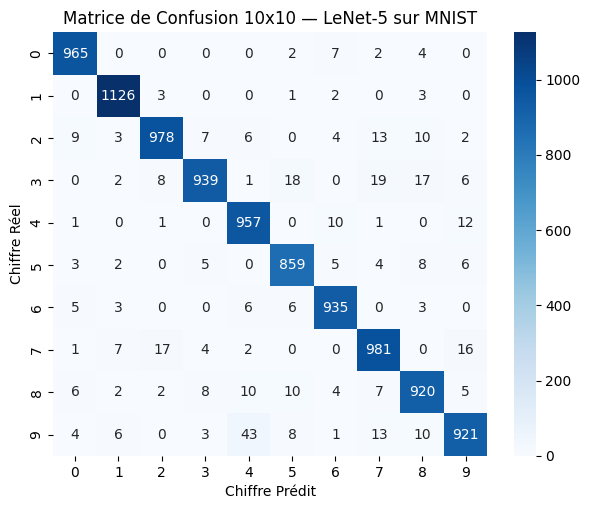

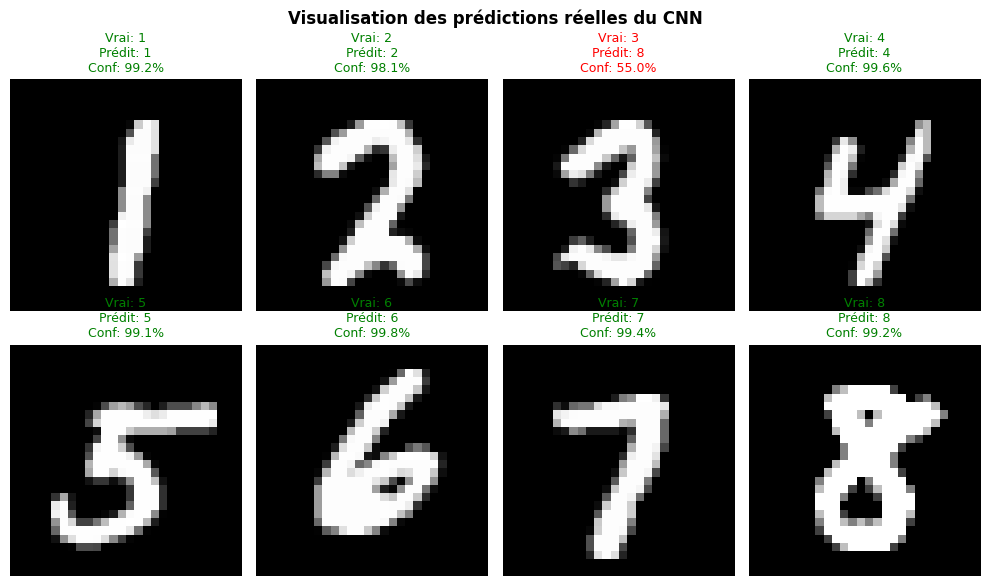

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

modele_cnn.eval()
labels_vrais, labels_predis = [], []
images_demo, labels_demo = None, None

with torch.no_grad():
    for inputs, labels in test_loader_cnn:
        images_demo, labels_demo = inputs, labels
        outputs = modele_cnn(inputs.to(device))
        _, predicted = torch.max(outputs, 1)
        labels_vrais.extend(labels.numpy())
        labels_predis.extend(predicted.cpu().numpy())

# 1. Tracé de la matrice de confusion 10x10
plt.figure(figsize=(7, 5.5))
sns.heatmap(confusion_matrix(labels_vrais, labels_predis), annot=True, fmt="d", cmap="Blues")
plt.title("Matrice de Confusion 10x10 — LeNet-5 sur MNIST")
plt.xlabel("Chiffre Prédit"), plt.ylabel("Chiffre Réel"), plt.show()

# 2. Grille de prédictions avec taux de confiance
outputs_demo = modele_cnn(images_demo.to(device))
probs = torch.softmax(outputs_demo, dim=1)
confs, preds_demo = torch.max(probs, 1)

fig, axes = plt.subplots(2, 4, figsize=(10, 6))
fig.suptitle("Visualisation des prédictions réelles du CNN", fontsize=12, weight='bold')
for i, ax in enumerate(axes.flat):
    img = images_demo[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    vrai, pred, conf = labels_demo[i].item(), preds_demo[i].item(), confs[i].item() * 100
    couleur = 'green' if vrai == pred else 'red'
    ax.set_title(f"Vrai: {vrai}\nPrédit: {pred}\nConf: {conf:.1f}%", color=couleur, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()